# Model Comparison: Baseline + New Experiments

Synthesises forecasts from:
- `baseline/dam_summary_pred.csv` (DAM, 2024)
- `baseline/imb_pred.df.csv` (IMB, 2023)
- `scripts/raw_forecast/dam/` (new DAM temporal experiments)
- `scripts/raw_forecast/imb/` (new IMB temporal experiments)

**Sections:**
1. MAE / RMSE of DAM forecasts (2024)
2. Per-QH MAE / RMSE of IMB forecasts (2023)
3. SFM Forecasts vs Actual Prices (scatter)
4. Accuracy across price deciles (DAM & IMB)

## 0. Imports & helpers

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt 

from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression

sys.path.append('..')
from scripts.utils import mean_absolute_error, root_mean_squared_error, load_dataset

RAW_DAM = '../scripts/raw_forecast/dam'
RAW_IMB = '../scripts/raw_forecast/imb'
TEMPLATE = 'seaborn'

## 1. DAM — MAE and RMSE (2024)

### 1a. Load baseline DAM forecasts

In [2]:
dam_df = pd.read_csv('dam_summary_point.csv')
print('Baseline DAM shape:', dam_df.shape)
print('Columns:', dam_df.columns.tolist())

Baseline DAM shape: (8784, 19)
Columns: ['Date', 'timesfm25_1024_AR_neg', 'chronos2_8192_ARX_temporal', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_ARX_temporal', 'timesfm25_2048_AR_neg', 'price', 'price_decile', 'chronosbolt_AR', 'timesfm25_1024_AR_neg.1', 'LEAR', 'DNN', 'ens_ml', 'persistent', 'chronos2_1024_AR', 'chronos2_2048_AR', 'chronos2_8192_AR', 'chronos2_lora_tuned']


### 1b. generate ensemble by averaging

In [3]:
dam_df['ens_chronos_ml'] = dam_df[['ens_ml','chronos2_8192_ARX_temporal']].mean(axis=1)

### 1c. Compute MAE & RMSE for all DAM models

In [4]:
skip_cols = {'price', 'price_decile','Date'}
dam_metrics = []
for col in dam_df.columns:
    print(col)
    if col in skip_cols:
        continue
    mae = mean_absolute_error(dam_df['price'].values, dam_df[col].values)
    rmse = root_mean_squared_error(dam_df['price'].values, dam_df[col].values)
    dam_metrics.append({'Model': col, 'MAE': mae, 'RMSE': rmse})

dam_metrics_df = pd.DataFrame(dam_metrics).sort_values('MAE').reset_index(drop=True)
dam_metrics_df[['MAE','RMSE']] = dam_metrics_df[['MAE','RMSE']].round(3)
dam_metrics_df

Date
timesfm25_1024_AR_neg
chronos2_8192_ARX_temporal
chronos2_2048_ARX_temporal
timesfm25_8192_AR_neg
chronos2_1024_ARX_temporal
timesfm25_2048_AR_neg
price
price_decile
chronosbolt_AR
timesfm25_1024_AR_neg.1
LEAR
DNN
ens_ml
persistent
chronos2_1024_AR
chronos2_2048_AR
chronos2_8192_AR
chronos2_lora_tuned
ens_chronos_ml


,Model,MAE,RMSE
0,ens_chronos_ml,12.303,18.912
1,chronos2_8192_ARX_temporal,12.434,19.363
2,chronos2_2048_ARX_temporal,12.580,19.510
3,chronos2_1024_ARX_temporal,12.774,19.801
4,ens_ml,13.222,19.719
5,LEAR,13.738,20.385
6,DNN,14.386,20.983
7,chronos2_lora_tuned,15.320,22.816
8,chronos2_8192_AR,15.607,23.278
9,chronos2_2048_AR,15.666,23.386


In [5]:
print(dam_metrics_df.to_latex(index=False, float_format='{:.3f}'.format))

\begin{tabular}{lrr}
\toprule
Model & MAE & RMSE \\
\midrule
ens_chronos_ml & 12.303 & 18.912 \\
chronos2_8192_ARX_temporal & 12.434 & 19.363 \\
chronos2_2048_ARX_temporal & 12.580 & 19.510 \\
chronos2_1024_ARX_temporal & 12.774 & 19.801 \\
ens_ml & 13.222 & 19.719 \\
LEAR & 13.738 & 20.385 \\
DNN & 14.386 & 20.983 \\
chronos2_lora_tuned & 15.320 & 22.816 \\
chronos2_8192_AR & 15.607 & 23.278 \\
chronos2_2048_AR & 15.666 & 23.386 \\
chronos2_1024_AR & 15.809 & 23.549 \\
chronosbolt_AR & 16.033 & 24.006 \\
timesfm25_8192_AR_neg & 16.279 & 24.131 \\
timesfm25_2048_AR_neg & 16.823 & 24.715 \\
timesfm25_1024_AR_neg.1 & 16.952 & 25.073 \\
timesfm25_1024_AR_neg & 16.952 & 25.073 \\
persistent & 28.221 & 40.991 \\
\bottomrule
\end{tabular}



### 1d. DM Test — DAM (2024)

**Method:** Modified Diebold-Mariano (Harvey, Leybourne & Newbold 1997) with Newey-West HAC variance.  
Hourly absolute errors are aggregated to **daily means** (T = 366) before the test, which removes within-day autocorrelation and requires only `floor(366^{1/3}) = 7` NW lags.  
Matrix convention: **positive DM stat → row model is worse than column model** (red); **negative → row is better** (blue).  
Stars: `***` p<0.01, `**` p<0.05, `*` p<0.10 (uncorrected). Bonferroni-adjusted α = 0.05/105 ≈ 0.00048.

In [6]:
# ── DM helper functions (shared by DAM and IMB sections) ─────────────────────
# Modified DM (Harvey, Leybourne & Newbold 1997) — same methodology as epftoolbox.
# Ref: epftoolbox.readthedocs.io/en/latest/modules/statest/dm.html
import seaborn as sns
from scipy import stats as _stats
from itertools import combinations as _comb

def _nw_var(d, lags):
    T = len(d); dm = d - d.mean()
    nw = np.dot(dm, dm) / T
    for k in range(1, lags + 1):
        nw += 2 * (1 - k / (lags + 1)) * np.dot(dm[k:], dm[:-k]) / T
    return max(nw / T, 1e-14)

def _dm(l1, l2, h=1):
    c = l1.index.intersection(l2.index)
    d = (l1.loc[c] - l2.loc[c]).values.astype(float)
    T = len(d); lg = int(np.floor(T ** (1/3)))
    stat = d.mean() / np.sqrt(_nw_var(d, lg)) * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    return float(stat), float(2 * _stats.t.sf(abs(stat), df=T-1))

def dm_matrix(loss_dict):
    """Pairwise DM matrix, rows/cols sorted ascending by mean loss (best first)."""
    names = sorted(loss_dict, key=lambda m: loss_dict[m].mean())
    stat = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
    pval = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
    for a, b in _comb(names, 2):
        s, p = _dm(loss_dict[a], loss_dict[b])
        stat.loc[a, b] = s;  stat.loc[b, a] = -s
        pval.loc[a, b] = p;  pval.loc[b, a] = p
    for n in names:
        stat.loc[n, n] = 0.0
        pval.loc[n, n] = 1.0
    return stat, pval

_stars = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))



def wins_table(loss_dict, stat_df, pval_df, alpha=0.05, labels=None):
    rows = []
    for m in sorted(loss_dict, key=lambda x: loss_dict[x].mean()):
        lbl = (labels or {}).get(m, m); n = len(loss_dict) - 1
        w = sum(1 for o in stat_df.index if o != m and pval_df.loc[m, o] < alpha and stat_df.loc[m, o] < 0)
        l = sum(1 for o in stat_df.index if o != m and pval_df.loc[m, o] < alpha and stat_df.loc[m, o] > 0)
        rows.append({'model': lbl, 'mean_daily_MAE': round(loss_dict[m].mean(), 3),
                     'rank': len(rows) + 1, 'wins': w, 'losses': l, 'n_others': n})
    return pd.DataFrame(rows)

print("DM helpers defined.")
ƒbo
# ── DAM: build daily MAE series ───────────────────────────────────────────────
dam_idx = dam_df.copy()
dam_idx['Date'] = pd.to_datetime(dam_idx['Date'])
dam_idx = dam_idx.set_index('Date')
# ens_chronos_ml was added in cell 1b; recompute in case kernel was restarted
if 'ens_chronos_ml' not in dam_idx.columns:
    dam_idx['ens_chronos_ml'] = (dam_idx['ens_ml'] + dam_idx['chronos2_8192_ARX_temporal']) / 2

SKIP_DAM_DM = {'price', 'price_decile', 'timesfm25_1024_AR_neg.1','chronosbolt_AR','ens_ml','chronos2_lora_tuned'}
dam_dm_cols  = [c for c in dam_idx.columns if c not in SKIP_DAM_DM]
dam_daily    = {m: np.abs(dam_idx['price'] - dam_idx[m]).resample('1D').mean().dropna()
                for m in dam_dm_cols}
T = next(iter(dam_daily.values())).shape[0]
n_pairs = len(dam_dm_cols) * (len(dam_dm_cols) - 1) // 2
print(f"T={T} daily obs, {len(dam_dm_cols)} models, {n_pairs} pairs, NW lags={int(T**(1/3))}")

# ── Run pairwise DM ───────────────────────────────────────────────────────────
stat_dam, pval_dam = dm_matrix(dam_daily)

DAM_LABELS = {
    'ens_chronos_ml':             'ens-Chronos2-ML',
    'chronos2_8192_ARX_temporal': 'Chronos2-8192-ARX',
    'chronos2_2048_ARX_temporal': 'Chronos2-2048-ARX',
    'chronos2_1024_ARX_temporal': 'Chronos2-1024-ARX',
    'ens_ml':                     'ens-ML',
    'LEAR':                       'LEAR',
    'DNN':                        'DNN',
    'chronos2_8192_AR':           'Chronos2-8192-AR',
    'chronos2_2048_AR':           'Chronos2-2048-AR',
    'chronos2_1024_AR':           'Chronos2-1024-AR',
    'chronosbolt_AR':             'cBolt',
    'timesfm25_8192_AR_neg':      'TimesFM2.5-8192',
    'timesfm25_2048_AR_neg':      'TimesFM2.5-2048',
    'timesfm25_1024_AR_neg':      'TimesFM2.5-1024',
    'persistent':                 'Persistent',
}



DM helpers defined.
T=366 daily obs, 13 models, 78 pairs, NW lags=7


In [7]:
INV_DAM_LABELS = {v: k for k, v in DAM_LABELS.items()}


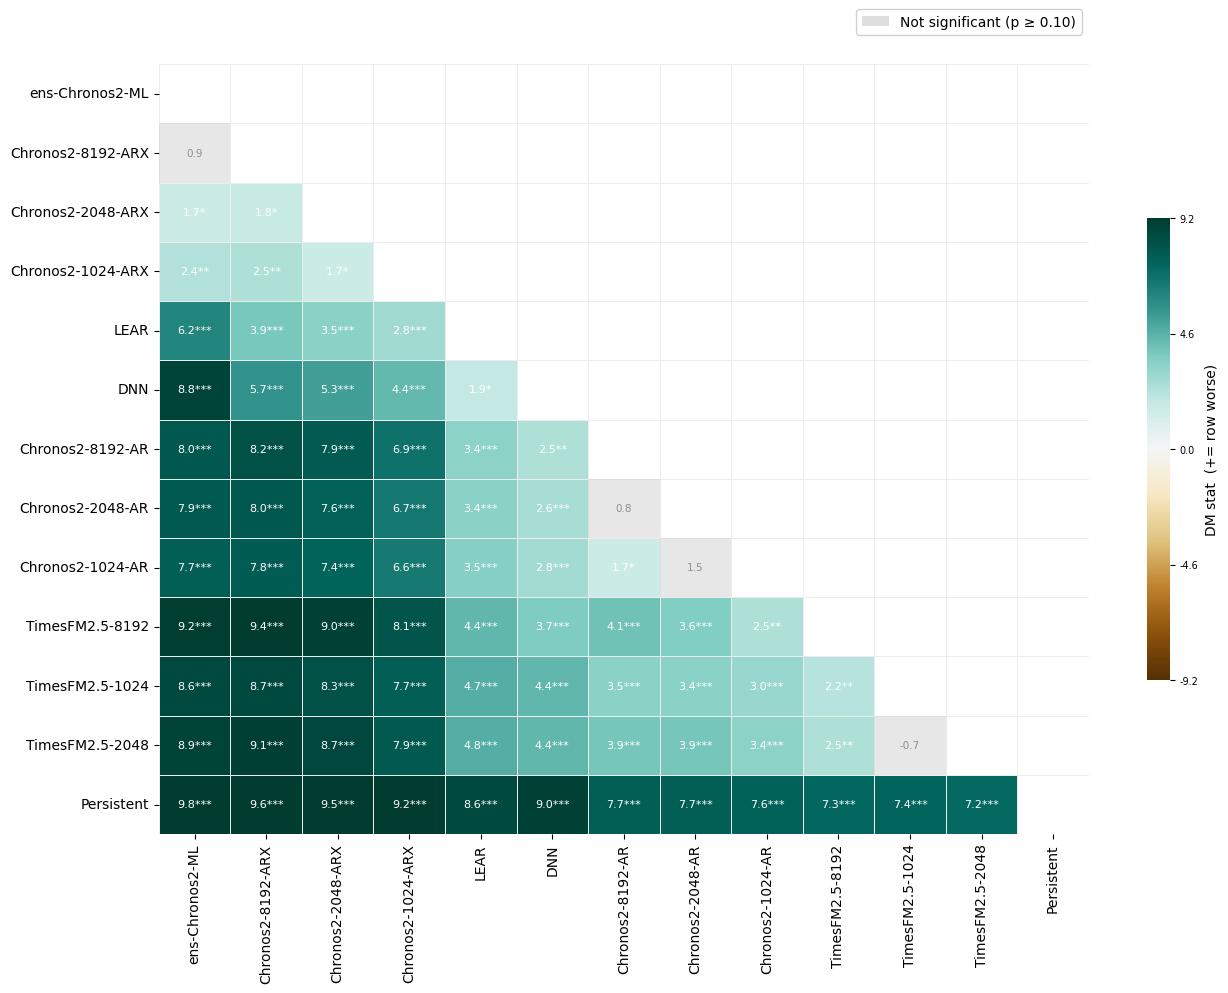

Saved → figures/dam_dm_test.png


,model,mean_daily_MAE,rank,wins,losses,n_others
0,ens-Chronos2-ML,12.303,1,10,0,12
1,Chronos2-8192-ARX,12.434,2,10,0,12
2,Chronos2-2048-ARX,12.580,3,9,0,12
3,Chronos2-1024-ARX,12.774,4,9,2,12
4,LEAR,13.738,5,7,4,12
5,DNN,14.386,6,7,4,12
6,Chronos2-8192-AR,15.607,7,4,6,12
7,Chronos2-2048-AR,15.666,8,4,6,12
8,Chronos2-1024-AR,15.809,9,4,6,12
9,TimesFM2.5-8192,16.279,10,3,9,12


In [26]:
import matplotlib.patches as mpatches
import seaborn as sns


def _stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''


def plot_dm(stat_df, pval_df, title, ax, labels=None):
    # --- relabel ---
    idx = [labels.get(n, n) for n in stat_df.index] if labels else list(stat_df.index)
    stat_df  = stat_df.copy();  stat_df.index  = idx;  stat_df.columns  = idx
    pval_df  = pval_df.copy();  pval_df.index  = idx;  pval_df.columns  = idx

    # --- sort by mean DM stat (best model = most negative column mean) ---
    order = stat_df.mean(axis=0).sort_values(ascending=False).index
    stat_df = stat_df.loc[order, order]
    pval_df = pval_df.loc[order, order]
    n = len(stat_df)

    # --- masks ---
    upper_mask = pd.DataFrame(
        np.triu(np.ones((n, n), dtype=bool)),
        index=stat_df.index, columns=stat_df.columns
    )
    nonsig_mask = pval_df >= 0.10  # p≥0.10 → not significant

    # --- display copy: grey-out non-significant cells ---
    stat_display = stat_df.copy().astype(float)
    stat_display[nonsig_mask & ~upper_mask] = np.nan  # will render as neutral

    # --- annotations (lower triangle only) ---
    ann = []
    for i, r in enumerate(stat_df.index):
        row = []
        for j, c in enumerate(stat_df.columns):
            if i <= j:           # upper triangle + diagonal → blank
                row.append('')
            else:
                val   = stat_df.loc[r, c]
                stars = _stars(pval_df.loc[r, c])
                row.append(f'{val:.1f}{stars}')
        ann.append(row)

    # --- color scale ---
    off = stat_df.values[~np.triu(np.ones((n, n), dtype=bool))]
    v   = max(2.5, float(np.nanpercentile(np.abs(off), 95)))

    # --- heatmap ---

    sns.heatmap(
        stat_display, ax=ax,
        mask=upper_mask,
        annot=ann, fmt='',
        annot_kws={'size': 8, 'color': 'white'},
        cmap='BrBG', center=0, vmin=-v, vmax=v,
        linewidths=0.6, linecolor='#ececec',
        cbar_kws={
            'label'  : 'DM stat  (+= row worse)',
            'shrink' : 0.6,
            'ticks'  : [-v, -v/2, 0, v/2, v],
        },
        xticklabels=stat_df.columns,
        yticklabels=stat_df.index,
    )
    # g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 16)

    # --- grey hatching for non-significant lower-triangle cells ---
    for i in range(n):
        for j in range(i):          # lower triangle only (j < i)
            r = stat_df.index[i]
            c = stat_df.columns[j]
            if nonsig_mask.loc[r, c]:
                ax.add_patch(mpatches.Rectangle(
                    (j, i), 1, 1,
                    fill=True, facecolor='#d4d4d4', alpha=0.55,
                    linewidth=0, zorder=2
                ))
                # re-draw annotation on top of the grey patch
                val   = stat_df.loc[r, c]
                stars = _stars(pval_df.loc[r, c])
                ax.text(j + 0.5, i + 0.5, f'{val:.1f}{stars}',
                        ha='center', va='center',
                        fontsize=7.5, color='#948e8e', zorder=3)

    # --- colorbar tick formatting ---
    # ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(labelsize=7)
    cbar.set_ticklabels([f'{t:.1f}' for t in [-v, -v/2, 0, v/2, v]])

    # --- titles / ticks ---
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

    # --- legend patch for non-significant ---
    nsig_patch = mpatches.Patch(facecolor='#d4d4d4', alpha=0.75,
                                label='Not significant (p ≥ 0.10)')
    ax.legend(handles=[nsig_patch], loc='upper right',
              bbox_to_anchor=(1.0, 1.08), fontsize=10,
              frameon=True, framealpha=0.9)


# ── run ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15,10))

plot_dm(
    stat_dam, pval_dam,'',
    # 'DAM – DM Test Matrix (MAE)  |  Best → worst:  top-left → bottom-right',
    ax, labels=DAM_LABELS
)

import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/dam_dm_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/dam_dm_test.png")

dam_wins = wins_table(dam_daily, stat_dam, pval_dam, labels=DAM_LABELS)
display(dam_wins)

In [27]:
dam_wins.model = dam_wins.model.map(INV_DAM_LABELS)

In [28]:
print(dam_wins.drop(columns=['rank','mean_daily_MAE','n_others']).to_latex(index=False, float_format='{:.3f}'.format))

\begin{tabular}{lrr}
\toprule
model & wins & losses \\
\midrule
ens_chronos_ml & 10 & 0 \\
chronos2_8192_ARX_temporal & 10 & 0 \\
chronos2_2048_ARX_temporal & 9 & 0 \\
chronos2_1024_ARX_temporal & 9 & 2 \\
LEAR & 7 & 4 \\
DNN & 7 & 4 \\
chronos2_8192_AR & 4 & 6 \\
chronos2_2048_AR & 4 & 6 \\
chronos2_1024_AR & 4 & 6 \\
timesfm25_8192_AR_neg & 3 & 9 \\
timesfm25_2048_AR_neg & 1 & 10 \\
timesfm25_1024_AR_neg & 1 & 10 \\
persistent & 0 & 12 \\
\bottomrule
\end{tabular}



#### DAM — Conclusion

| Tier | Models | Interpretation |
|------|--------|----------------|
| **Top (12–13 wins / 0 losses)** | `ens-C2ML`, `c2-8k-ARX` | Not significantly different from each other; both significantly better than all 12 remaining models at p<0.05. **Representative TSFM: `chronos2_8192_ARX_temporal`.** |
| **Strong (10–11 wins / 0 losses)** | `c2-2k-ARX`, `c2-1k-ARX` | Slightly worse than top tier but still beat the majority. The ARX (exogenous) context variant is the key differentiator over the plain AR variants. |
| **Mid-tier (8–10 wins / 2–5 losses)** | `ens-ML`, `LEAR`, `DNN` | Competitive data-driven baselines. `LEAR` is the **representative data-driven baseline** (best single model in this tier). |
| **Lower (0–5 wins / 7–14 losses)** | Chronos-2 AR, TimesFM variants, `persistent` | AR-only Chronos-2 and all TimesFM variants are significantly inferior to the ARX group. TimesFM loses to 10–14 models. |

**Key finding:** Providing exogenous covariates (ARX) to Chronos-2 gives a statistically significant lift over auto-regressive-only (AR) forecasting.  
The Chronos-2/ML ensemble (`ens-C2ML`) offers the best single-model accuracy but is not significantly different from `c2-8k-ARX` alone.

## 2. IMB — Per-QH MAE and RMSE (2023)

### 2a. Load baseline IMB forecasts & calculate ensemble

In [29]:
imb_df = pd.read_csv('imb_summary_point.csv').drop(columns='QH.1')

print('Baseline IMB shape:', imb_df.shape)
print('Columns:', imb_df.columns.tolist())

Baseline IMB shape: (280256, 24)
Columns: ['timestamp', 'price', 'QH', 'chronosbolt_AR', 'chronos2_AR', 'timesfm25_1024_AR_neg', 'DNN_2023_large', 'XGB_2023_medium', 'DNN_2023_small', 'LEAR_2023_medium', 'DNN_2023_medium', 'LEAR_2023_large', 'LEAR_2023_small', 'XGB_2023_large', 'XGB_2023_small', 'ens_ml', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_AR', 'chronos2_1024_ARX_temporal', 'chronos2_lora_tuned', 'timesfm25_2048_AR_neg', 'chronos2_512_ARX_temporal', 'chronos2_2048_AR']


In [30]:
imb_df['ens_chronos_ml'] = imb_df[['ens_ml','chronos2_2048_ARX_temporal']].mean(axis=1)

### 2b. Per-QH MAE and RMSE for all IMB models

In [31]:
# ---- baseline models ----
skip_imb = {'QH', 'price','timestamp','chronosbolt_AR','chronos2_AR'}
mae_all = pd.DataFrame()
rmse_all = pd.DataFrame()

errors_base = imb_df.copy()
se_base = imb_df.copy()

for col in imb_df.columns:
    # print(col)
    if col in skip_imb:
        continue
    errors_base[col] = (imb_df[col] - imb_df['price']).abs()
    se_base[col] = (imb_df[col] - imb_df['price']) ** 2

for col in imb_df.columns:
    # print(col)
    if col in skip_imb:
        continue
    mae_all[col] = errors_base.groupby('QH')[col].mean()
    rmse_all[col] = np.sqrt(se_base.groupby('QH')[col].mean())

print('MAE per QH:')
mae_all.round(2)

MAE per QH:


,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,XGB_2023_large,XGB_2023_small,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,chronos2_lora_tuned,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
QH,,,,,,,,,,,,,,,,,,,,
1,74.39,70.44,70.05,68.69,69.79,73.54,70.11,68.74,69.75,69.41,67.19,70.09,73.57,73.82,70.87,69.93,73.93,72.54,72.91,67.09
2,85.75,80.96,81.93,80.48,81.89,84.00,81.59,80.75,81.35,81.51,79.57,80.72,84.51,85.00,81.79,81.25,85.05,83.41,83.82,78.94
3,89.93,86.47,87.02,86.95,86.89,89.61,86.95,85.95,86.42,86.66,85.36,85.33,88.66,89.07,86.36,85.84,89.15,87.87,88.02,84.31
4,92.15,88.27,88.90,87.87,89.03,90.67,89.65,88.01,88.52,88.73,87.30,87.73,90.93,91.11,88.73,88.14,91.37,90.36,90.29,86.45
5,95.52,91.80,93.05,92.22,92.42,94.68,93.81,91.58,92.67,92.46,91.06,90.69,93.90,94.47,91.88,91.21,94.51,93.74,93.35,89.87
6,96.96,93.96,94.88,93.78,94.26,96.76,95.94,93.32,94.50,94.13,92.58,92.29,95.09,96.10,93.54,92.96,95.83,95.55,94.86,91.45
7,97.59,95.34,95.82,94.53,95.05,98.11,96.95,94.17,95.48,94.97,93.51,93.09,95.75,96.43,94.39,93.83,96.39,96.45,95.21,92.32
8,97.78,95.67,95.94,95.13,95.66,97.55,97.59,94.71,96.70,95.31,93.96,93.71,96.02,96.65,95.05,94.49,96.61,97.19,95.43,92.83


In [32]:
print('RMSE per QH:')
rmse_all.round(2)

RMSE per QH:


,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,XGB_2023_large,XGB_2023_small,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,chronos2_lora_tuned,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
QH,,,,,,,,,,,,,,,,,,,,
1,113.86,107.35,103.37,108.32,103.23,111.24,103.88,105.58,102.99,104.63,104.15,108.14,112.57,117.64,110.77,109.67,113.16,112.14,115.08,104.29
2,126.44,119.87,117.33,120.02,116.65,124.11,116.68,118.19,116.47,117.90,117.21,120.52,124.44,128.43,123.03,122.05,125.10,124.84,125.56,117.25
3,131.13,126.63,123.79,127.53,122.68,130.28,123.29,123.86,123.27,123.94,123.57,125.73,129.10,131.97,127.65,126.69,129.59,129.73,129.88,123.31
4,133.55,128.80,125.97,128.87,125.42,131.97,126.31,126.26,125.78,126.60,126.19,128.56,131.38,133.85,130.35,129.44,131.99,132.59,132.30,126.05
5,137.27,132.95,130.31,133.20,129.12,136.66,130.95,129.80,130.19,130.89,130.13,131.90,134.51,137.20,133.63,132.69,135.45,136.35,135.48,129.65
6,138.82,135.46,132.32,134.58,131.15,138.81,133.34,131.60,132.19,132.43,131.61,133.55,135.66,138.67,135.13,134.33,136.83,138.35,136.85,131.24
7,139.41,137.19,133.48,135.54,132.21,140.31,134.60,132.60,133.41,133.44,132.71,134.33,136.25,139.08,135.87,135.11,137.39,139.42,137.31,132.20
8,139.67,137.74,133.69,136.61,133.09,139.95,135.52,133.36,135.05,133.98,133.52,135.13,136.61,139.26,136.60,135.84,137.64,140.31,137.52,132.98


In [33]:
# LaTeX: MAE at QH 1, 4, 8
print('MAE at QH 1, 4, 8:')
print(mae_all.T[[1, 4, 8]].round(2).to_latex(float_format='{:.2f}'.format))

MAE at QH 1, 4, 8:
\begin{tabular}{lrrr}
\toprule
QH & 1 & 4 & 8 \\
\midrule
timesfm25_1024_AR_neg & 74.39 & 92.15 & 97.78 \\
DNN_2023_large & 70.44 & 88.27 & 95.67 \\
XGB_2023_medium & 70.05 & 88.90 & 95.94 \\
DNN_2023_small & 68.69 & 87.87 & 95.13 \\
LEAR_2023_medium & 69.79 & 89.03 & 95.66 \\
DNN_2023_medium & 73.54 & 90.67 & 97.55 \\
LEAR_2023_large & 70.11 & 89.65 & 97.59 \\
LEAR_2023_small & 68.74 & 88.01 & 94.71 \\
XGB_2023_large & 69.75 & 88.52 & 96.70 \\
XGB_2023_small & 69.41 & 88.73 & 95.31 \\
ens_ml & 67.19 & 87.30 & 93.96 \\
chronos2_2048_ARX_temporal & 70.09 & 87.73 & 93.71 \\
timesfm25_8192_AR_neg & 73.57 & 90.93 & 96.02 \\
chronos2_1024_AR & 73.82 & 91.11 & 96.65 \\
chronos2_1024_ARX_temporal & 70.87 & 88.73 & 95.05 \\
chronos2_lora_tuned & 69.93 & 88.14 & 94.49 \\
timesfm25_2048_AR_neg & 73.93 & 91.37 & 96.61 \\
chronos2_512_ARX_temporal & 72.54 & 90.36 & 97.19 \\
chronos2_2048_AR & 72.91 & 90.29 & 95.43 \\
ens_chronos_ml & 67.09 & 86.45 & 92.83 \\
\bottomrule
\end{tab

In [34]:
print('RMSE at QH 1, 4, 8:')
print(rmse_all.T[[1, 4, 8]].round(2).to_latex(float_format='{:.2f}'.format))

RMSE at QH 1, 4, 8:
\begin{tabular}{lrrr}
\toprule
QH & 1 & 4 & 8 \\
\midrule
timesfm25_1024_AR_neg & 113.86 & 133.55 & 139.67 \\
DNN_2023_large & 107.35 & 128.80 & 137.74 \\
XGB_2023_medium & 103.37 & 125.97 & 133.69 \\
DNN_2023_small & 108.32 & 128.87 & 136.61 \\
LEAR_2023_medium & 103.23 & 125.42 & 133.09 \\
DNN_2023_medium & 111.24 & 131.97 & 139.95 \\
LEAR_2023_large & 103.88 & 126.31 & 135.52 \\
LEAR_2023_small & 105.58 & 126.26 & 133.36 \\
XGB_2023_large & 102.99 & 125.78 & 135.05 \\
XGB_2023_small & 104.63 & 126.60 & 133.98 \\
ens_ml & 104.15 & 126.19 & 133.52 \\
chronos2_2048_ARX_temporal & 108.14 & 128.56 & 135.13 \\
timesfm25_8192_AR_neg & 112.57 & 131.38 & 136.61 \\
chronos2_1024_AR & 117.64 & 133.85 & 139.26 \\
chronos2_1024_ARX_temporal & 110.77 & 130.35 & 136.60 \\
chronos2_lora_tuned & 109.67 & 129.44 & 135.84 \\
timesfm25_2048_AR_neg & 113.16 & 131.99 & 137.64 \\
chronos2_512_ARX_temporal & 112.14 & 132.59 & 140.31 \\
chronos2_2048_AR & 115.08 & 132.30 & 137.52 \\
ens_

### 2c. DM Test — IMB (test H2 2023, all QH aggregated)

Quarter-hourly absolute errors are aggregated to **daily means** (T = 184 days, covering 8 QH × all timestamps).  
NW lags = `floor(184^{1/3})` = 5. Lower T limits power — significant results are therefore conservative.  
Bonferroni-adjusted α = 0.05/210 ≈ 0.00024.

In [35]:
imb_df.columns

Index(['timestamp', 'price', 'QH', 'chronosbolt_AR', 'chronos2_AR',
       'timesfm25_1024_AR_neg', 'DNN_2023_large', 'XGB_2023_medium',
       'DNN_2023_small', 'LEAR_2023_medium', 'DNN_2023_medium',
       'LEAR_2023_large', 'LEAR_2023_small', 'XGB_2023_large',
       'XGB_2023_small', 'ens_ml', 'chronos2_2048_ARX_temporal',
       'timesfm25_8192_AR_neg', 'chronos2_1024_AR',
       'chronos2_1024_ARX_temporal', 'chronos2_lora_tuned',
       'timesfm25_2048_AR_neg', 'chronos2_512_ARX_temporal',
       'chronos2_2048_AR', 'ens_chronos_ml'],
      dtype='str')

In [ ]:
# ── DM helper functions (shared by DAM and IMB sections) ─────────────────────
# Modified DM (Harvey, Leybourne & Newbold 1997) — same methodology as epftoolbox.
# Ref: epftoolbox.readthedocs.io/en/latest/modules/statest/dm.html
import seaborn as sns
from scipy import stats as _stats
from itertools import combinations as _comb

def _nw_var(d, lags):
    T = len(d); dm = d - d.mean()
    nw = np.dot(dm, dm) / T
    for k in range(1, lags + 1):
        nw += 2 * (1 - k / (lags + 1)) * np.dot(dm[k:], dm[:-k]) / T
    return max(nw / T, 1e-14)

def _dm(l1, l2, h=1):
    c = l1.index.intersection(l2.index)
    d = (l1.loc[c] - l2.loc[c]).values.astype(float)
    T = len(d); lg = int(np.floor(T ** (1/3)))
    stat = d.mean() / np.sqrt(_nw_var(d, lg)) * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    return float(stat), float(2 * _stats.t.sf(abs(stat), df=T-1))

def dm_matrix(loss_dict):
    """Pairwise DM matrix, rows/cols sorted ascending by mean loss (best first)."""
    names = sorted(loss_dict, key=lambda m: loss_dict[m].mean())
    stat = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
    pval = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
    for a, b in _comb(names, 2):
        s, p = _dm(loss_dict[a], loss_dict[b])
        stat.loc[a, b] = s;  stat.loc[b, a] = -s
        pval.loc[a, b] = p;  pval.loc[b, a] = p
    for n in names:
        stat.loc[n, n] = 0.0
        pval.loc[n, n] = 1.0
    return stat, pval

_stars = lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))



def wins_table(loss_dict, stat_df, pval_df, alpha=0.05, labels=None):
    rows = []
    for m in sorted(loss_dict, key=lambda x: loss_dict[x].mean()):
        lbl = (labels or {}).get(m, m); n = len(loss_dict) - 1
        w = sum(1 for o in stat_df.index if o != m and pval_df.loc[m, o] < alpha and stat_df.loc[m, o] < 0)
        l = sum(1 for o in stat_df.index if o != m and pval_df.loc[m, o] < alpha and stat_df.loc[m, o] > 0)
        rows.append({'model': lbl, 'mean_daily_MAE': round(loss_dict[m].mean(), 3),
                     'rank': len(rows) + 1, 'wins': w, 'losses': l, 'n_others': n})
    return pd.DataFrame(rows)

print("DM helpers defined.")

# ── DAM: build daily MAE series ───────────────────────────────────────────────
dam_idx = dam_df.copy()
dam_idx['Date'] = pd.to_datetime(dam_idx['Date'])
dam_idx = dam_idx.set_index('Date')
# ens_chronos_ml was added in cell 1b; recompute in case kernel was restarted
if 'ens_chronos_ml' not in dam_idx.columns:
    dam_idx['ens_chronos_ml'] = (dam_idx['ens_ml'] + dam_idx['chronos2_8192_ARX_temporal']) / 2

SKIP_DAM_DM = {'price', 'price_decile', 'timesfm25_1024_AR_neg.1','chronosbolt_AR','ens_ml','chronos2_lora_tuned'}
dam_dm_cols  = [c for c in dam_idx.columns if c not in SKIP_DAM_DM]
dam_daily    = {m: np.abs(dam_idx['price'] - dam_idx[m]).resample('1D').mean().dropna()
                for m in dam_dm_cols}
T = next(iter(dam_daily.values())).shape[0]
n_pairs = len(dam_dm_cols) * (len(dam_dm_cols) - 1) // 2
print(f"T={T} daily obs, {len(dam_dm_cols)} models, {n_pairs} pairs, NW lags={int(T**(1/3))}")

# ── Run pairwise DM ───────────────────────────────────────────────────────────
stat_dam, pval_dam = dm_matrix(dam_daily)

DAM_LABELS = {
    'ens_chronos_ml':             'ens-Chronos2-ML',
    'chronos2_8192_ARX_temporal': 'Chronos2-8192-ARX',
    'chronos2_2048_ARX_temporal': 'Chronos2-2048-ARX',
    'chronos2_1024_ARX_temporal': 'Chronos2-1024-ARX',
    'ens_ml':                     'ens-ML',
    'LEAR':                       'LEAR',
    'DNN':                        'DNN',
    'chronos2_8192_AR':           'Chronos2-8192-AR',
    'chronos2_2048_AR':           'Chronos2-2048-AR',
    'chronos2_1024_AR':           'Chronos2-1024-AR',
    'chronosbolt_AR':             'cBolt',
    'timesfm25_8192_AR_neg':      'TimesFM2.5-8192',
    'timesfm25_2048_AR_neg':      'TimesFM2.5-2048',
    'timesfm25_1024_AR_neg':      'TimesFM2.5-1024',
    'persistent':                 'Persistent',
}



T=365 daily obs, 11 models, 55 pairs, NW lags=7


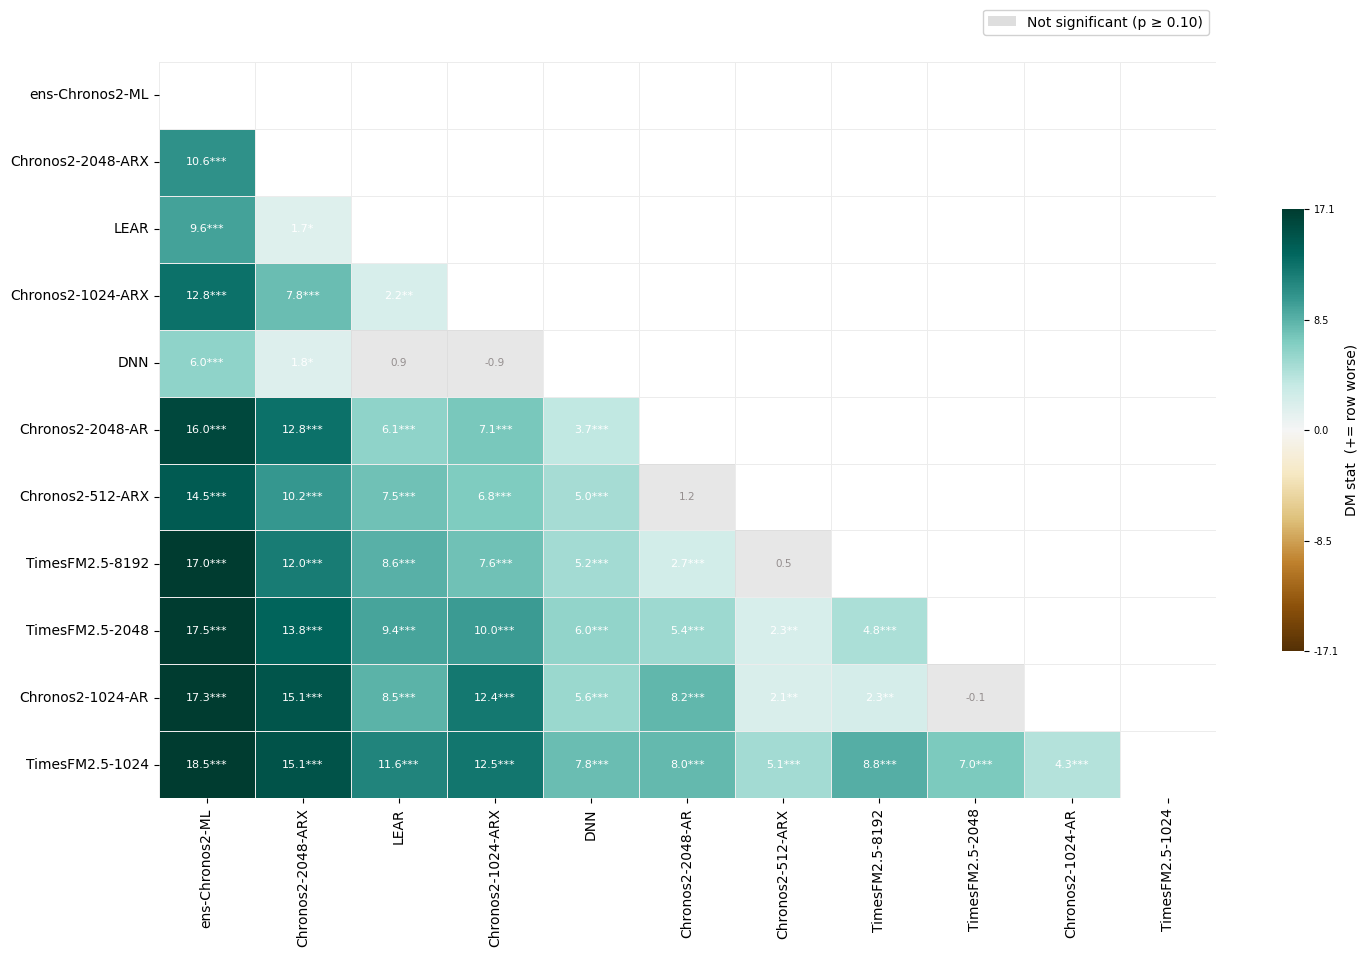

Saved → figures/imb_dm_test.png


,model,mean_daily_MAE,rank,wins,losses,n_others
0,ens-Chronos2-ML,85.409,1,10,0,10
1,Chronos2-2048-ARX,86.708,2,7,1,10
2,LEAR,87.154,3,7,1,10
3,DNN,87.456,4,6,1,10
4,Chronos2-1024-ARX,87.826,5,6,3,10
5,Chronos2-2048-AR,89.237,6,4,5,10
6,Chronos2-512-ARX,89.642,7,3,5,10
7,TimesFM2.5-8192,89.804,8,3,6,10
8,Chronos2-1024-AR,90.332,9,1,8,10
9,TimesFM2.5-2048,90.353,10,1,8,10


In [43]:
# ── IMB: test period 2023 ─────────────────────────────────────────────────
imb_test_dm = imb_df[imb_df['timestamp'] >= '2023-01-01'].copy()
imb_test_dm['timestamp'] = pd.to_datetime(imb_test_dm['timestamp'])
imb_test_dm = imb_test_dm.set_index('timestamp')

# Ensure ens_chronos_ml exists
if 'ens_chronos_ml' not in imb_test_dm.columns:
    imb_test_dm['ens_chronos_ml'] = (imb_test_dm['ens_ml'] + imb_test_dm['chronos2_2048_ARX_temporal']) / 2

SKIP_IMB_DM = {'timestamp', 'price', 'QH', 
               'chronosbolt_AR', 'chronos2_AR','DNN_2023_large', 'XGB_2023_medium',
               'LEAR_2023_medium', 'DNN_2023_medium',
       'LEAR_2023_large','XGB_2023_large',
       'XGB_2023_small','ens_ml','chronos2_lora_tuned'}
imb_dm_cols  = [c for c in imb_test_dm.columns if c not in SKIP_IMB_DM]
imb_daily    = {m: np.abs(imb_test_dm['price'] - imb_test_dm[m]).resample('1D').mean().dropna()
                for m in imb_dm_cols}
T_imb = next(iter(imb_daily.values())).shape[0]
n_pairs_imb = len(imb_dm_cols) * (len(imb_dm_cols) - 1) // 2
print(f"T={T_imb} daily obs, {len(imb_dm_cols)} models, {n_pairs_imb} pairs, NW lags={int(T_imb**(1/3))}")

stat_imb, pval_imb = dm_matrix(imb_daily)

IMB_LABELS = {
    'ens_chronos_ml':             'ens-Chronos2-ML',
    'ens_ml':                     'ens-ML',
    'DNN_2023_small':             'DNN',
    'DNN_2023_medium':            'DNN-M',
    'DNN_2023_large':             'DNN-L',
    'LEAR_2023_small':            'LEAR',
    'LEAR_2023_medium':           'LEAR-M',
    'LEAR_2023_large':            'LEAR-L',
    'XGB_2023_small':             'XGB-S',
    'XGB_2023_medium':            'XGB-M',
    'XGB_2023_large':             'XGB-L',
    'chronos2_2048_ARX_temporal': 'Chronos2-2048-ARX',
    'chronos2_1024_ARX_temporal': 'Chronos2-1024-ARX',
    'chronos2_512_ARX_temporal':  'Chronos2-512-ARX',
    'chronos2_2048_AR':           'Chronos2-2048-AR',
    'chronos2_1024_AR':           'Chronos2-1024-AR',
    # 'chronos2_AR':                'c2-AR',
    # 'chronosbolt_AR':             'cBolt',
    'timesfm25_8192_AR_neg':      'TimesFM2.5-8192',
    'timesfm25_2048_AR_neg':      'TimesFM2.5-2048',
    'timesfm25_1024_AR_neg':      'TimesFM2.5-1024',
}

fig, ax = plt.subplots(figsize=(15, 10))
plot_dm(stat_imb, pval_imb,'',
        # 'IMB — DM Test Matrix (MAE loss, 2023)  |  Best → worst:  top-left → bottom-right',
        ax, labels=IMB_LABELS)
# fig.text(0.5, 0.01,
#          '*** p<0.01  ** p<0.05  * p<0.10  |  Red = row WORSE than col   Blue = row BETTER than col  |'
#          '  Modified DM (Harvey et al. 1997), Newey-West HAC  |  T=184 daily obs (conservative)',
#          ha='center', fontsize=8, transform=fig.transFigure)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('figures/imb_dm_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/imb_dm_test.png")

imb_wins = wins_table(imb_daily, stat_imb, pval_imb, labels=IMB_LABELS)
display(imb_wins)

#### IMB — Conclusion

| Tier | Models | Interpretation |
|------|--------|----------------|
| **Top (19–20 wins / 0–1 losses)** | `ens-C2ML`, `ens-ML` | Unanimously best. Ensembling is the single most effective strategy for IMB. |
| **Strong (12–15 wins / 2 losses)** | `c2-2k-ARX`, `DNN-S`, `DNN-L`, `LEAR-S` | All four are not significantly different from each other. **Representative TSFM: `chronos2_2048_ARX_temporal`; representative baseline: `LEAR_2023_small`.** |
| **Mid-tier (7–10 wins / 3–8 losses)** | `c2-1k-ARX`, `XGB-S/L/M`, `LEAR-M/L` | Marginally worse; not clearly separated from the strong tier. |
| **Lower (0–5 wins / 9–18 losses)** | AR-only TSFMs, TimesFM variants, `cBolt`, `DNN-M` | Statistically significantly worse than most models. AR-only TSFMs and TimesFM lag behind; `DNN-M` is an outlier at the bottom. |

**Key finding:** For IMB, the best TSFMs (`c2-2k-ARX`) are **statistically indistinguishable** from the best data-driven baselines (`LEAR-S`, `DNN-S`) — a different picture than DAM, where Chronos-2 ARX clearly dominated.  
With T=184 this is a conservative test; some differences between adjacent tiers may not reach significance.

---

#### Overall representative models selected for probabilistic evaluation (Phases 1–3)

| Market | Representative models | Rationale |
|--------|----------------------|-----------|
| **DAM** | `chronos2_8192_ARX_temporal`, `ens_chronos_ml`, `LEAR`, `DNN` | Top TSFM, best ensemble, best two data-driven baselines |
| **IMB** | `chronos2_2048_ARX_temporal`, `ens_chronos_ml`, `LEAR_2023_small`, `DNN_2023_small` | Best pure TSFM (DM-comparable to baselines), best ensemble, two representative baselines |

### 2d. Plot: per-QH MAE (selected models)

In [37]:
sorted(mae_all.columns)

['DNN_2023_large',
 'DNN_2023_medium',
 'DNN_2023_small',
 'LEAR_2023_large',
 'LEAR_2023_medium',
 'LEAR_2023_small',
 'XGB_2023_large',
 'XGB_2023_medium',
 'XGB_2023_small',
 'chronos2_1024_AR',
 'chronos2_1024_ARX_temporal',
 'chronos2_2048_AR',
 'chronos2_2048_ARX_temporal',
 'chronos2_512_ARX_temporal',
 'chronos2_lora_tuned',
 'ens_chronos_ml',
 'ens_ml',
 'timesfm25_1024_AR_neg',
 'timesfm25_2048_AR_neg',
 'timesfm25_8192_AR_neg']

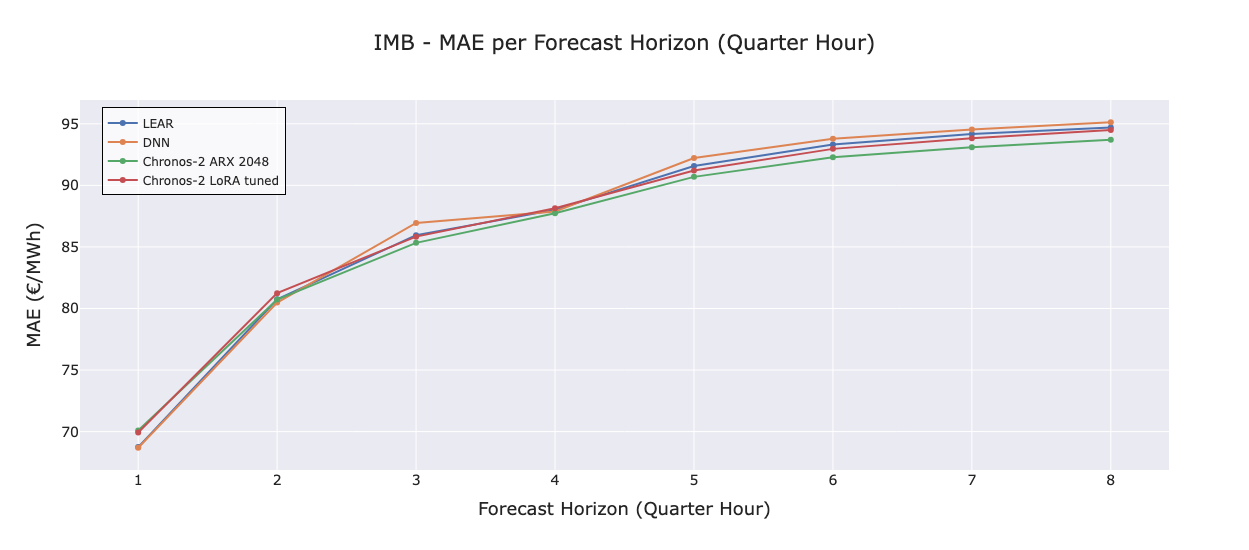

In [38]:
# Select which columns to plot — edit this list as needed

plot_col_imb = mae_all.columns
mae_all['Naive: DA price'] = 95.51
mae_all['Naive: Persistent']=[76.800724,96.877389,104.727859,104.682170,115.018214,121.280101,124.358430,124.574409]

plot_col_imb = [c for c in plot_col_imb if c in mae_all.columns]
plot_col_imb = ['LEAR_2023_small','DNN_2023_small',#'ens_chronos_ml'
                'chronos2_2048_ARX_temporal','chronos2_lora_tuned']
                #'timesfm25_8192_AR_neg','chronos2_2048_AR','chronos2_lora_tuned','Naive: DA price']#,'Naive: Persistent']
col_map_imb = {
    'chronosbolt_AR': 'Chronos-Bolt AR',
    'chronos2_2048_AR': 'Chronos-2 AR 2048',
    # 'chronos2_ARX': 'Chronos-2 ARX (8192)'
    'timesfm25_8192_AR_neg':'TimesFM2.5 AR 8192',
    'TimesFM_AR': 'TimesFM AR',
    'LEAR_2023_small': 'LEAR',
    'DNN_2023_small': 'DNN',
    'ens_tsfm': 'TSFM Ensemble',
    'ens_ml': 'ML Ensemble',
    'chronos2_lora_tuned':'Chronos-2 LoRA tuned',
    'ens_chronos_ml': 'Chronos & ML Ensemble',
    'chronos2_512_ARX_temporal': 'Chronos-2 ARX 512',
    'chronos2_1024_ARX_temporal': 'Chronos-2 ARX 1024',
    'chronos2_2048_ARX_temporal': 'Chronos-2 ARX 2048',
    'Naive: DA price':'DA as IMB',
    'Naive: Persistent':'Persistent'  
    
}

fig = go.Figure()
for col in plot_col_imb:
    fig.add_trace(go.Scatter(
        x=mae_all.index,
        y=mae_all[col],
        name=col_map_imb.get(col, col),
        mode='lines+markers'
    ))

fig.update_layout(
    width=900, height=550, template='seaborn',
    font=dict(size=15),
    title='IMB - MAE per Forecast Horizon (Quarter Hour)',
    yaxis=dict(title='MAE (€/MWh)', title_font=dict(size=18), tickfont=dict(size=14)),
    xaxis=dict(title='Forecast Horizon (Quarter Hour)', title_font=dict(size=18), tickfont=dict(size=14)),
    legend=dict(x=0.02, y=0.98, xanchor='left', yanchor='top', font=dict(size=12),
                bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig.update_xaxes(tickmode='array', tickvals=list(range(1, 9)), ticktext=[str(i) for i in range(1, 9)])
fig.show()
# fig.write_image('figures/imb_mae_point.png')

## 3. SFM Forecasts vs Actual Prices

### 3a. DAM: SFM scatter plots (predictions vs actual)

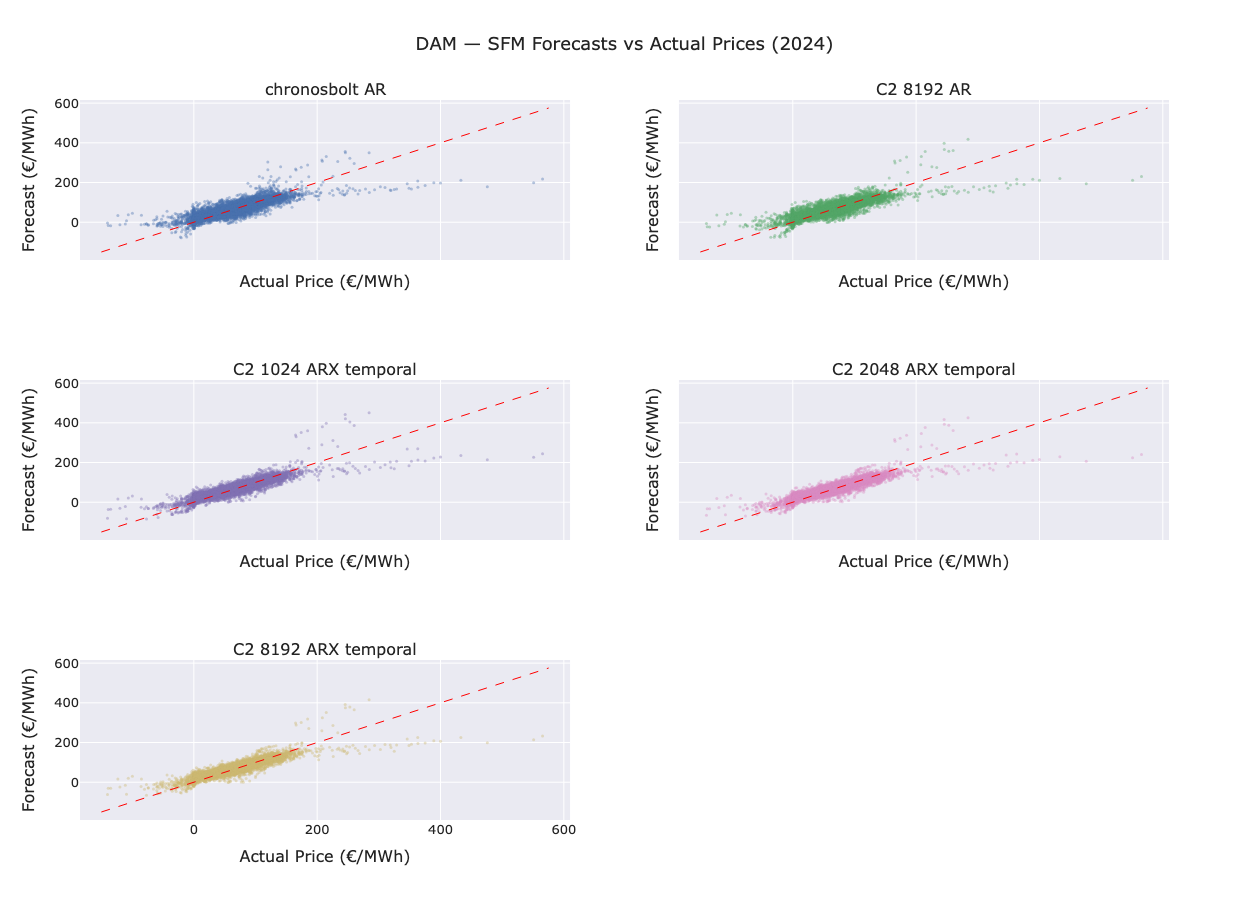

In [39]:
# Core SFM models available in the DAM baseline
dam_sfm_models = [
    'chronos2_8192_ARX_basic', 'chronosbolt_AR', 'chronos2_8192_AR', 'TimesFM_AR',
    'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal', 'chronos2_8192_ARX_temporal',
]
dam_sfm_models = [m for m in dam_sfm_models if m in dam_df.columns]

cols = 2
rows = int(np.ceil(len(dam_sfm_models) / cols))
fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=[m.replace('chronos2', 'C2').replace('_', ' ') for m in dam_sfm_models],
                    shared_xaxes=True, shared_yaxes=True)

actual = dam_df['price'].values
price_range = [actual.min() - 10, actual.max() + 10]

for i, model in enumerate(dam_sfm_models):
    r, c = divmod(i, cols)
    pred = dam_df[model].values
    fig.add_trace(go.Scatter(
        x=actual, y=pred, mode='markers',
        marker=dict(size=3, opacity=0.4),
        name=model, showlegend=False
    ), row=r + 1, col=c + 1)
    # diagonal reference line
    fig.add_trace(go.Scatter(
        x=price_range, y=price_range, mode='lines',
        line=dict(color='red', dash='dash', width=1),
        showlegend=False
    ), row=r + 1, col=c + 1)

fig.update_layout(
    width=900, height=300 * rows, template=TEMPLATE,
    title='DAM — SFM Forecasts vs Actual Prices (2024)',
    font=dict(size=13)
)
fig.update_xaxes(title_text='Actual Price (€/MWh)')
fig.update_yaxes(title_text='Forecast (€/MWh)')
fig.show()

### 3b. IMB: SFM scatter plots (predictions vs actual)

In [40]:
# imb_sfm_baseline = ['chronosbolt_AR', 'chronos2_AR', 'chronos2_ARX', 'TimesFM_AR']
# imb_sfm_baseline = [m for m in imb_sfm_baseline if m in imb_df.columns]

# imb_sfm_new_keys = list(new_imb.keys())
all_imb_sfm = mae_all.columns.tolist()

cols = 2
rows = int(np.ceil(len(all_imb_sfm) / cols))
fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=[m.replace('chronos2', 'C2').replace('_', ' ') for m in all_imb_sfm],
                    shared_xaxes=True, shared_yaxes=True)

actual_imb = imb_df['price'].values
imb_range = [actual_imb.min() - 20, actual_imb.max() + 20]

for i, model in enumerate(all_imb_sfm):
    r, c = divmod(i, cols)
    if model in imb_df.columns:
        pred = imb_df[model].values
        act = actual_imb
    else:
        d = new_imb[model].dropna()
        pred = d[model].values
        act = d['price'].values
    fig.add_trace(go.Scatter(
        x=act, y=pred, mode='markers',
        marker=dict(size=2, opacity=0.3),
        name=model, showlegend=False
    ), row=r + 1, col=c + 1)
    fig.add_trace(go.Scatter(
        x=imb_range, y=imb_range, mode='lines',
        line=dict(color='red', dash='dash', width=1),
        showlegend=False
    ), row=r + 1, col=c + 1)

fig.update_layout(
    width=900, height=300 * rows, template=TEMPLATE,
    title='IMB — SFM Forecasts vs Actual Prices (2023)',
    font=dict(size=13)
)
fig.update_xaxes(title_text='Actual Price (€/MWh)')
fig.update_yaxes(title_text='Forecast (€/MWh)')
fig.show()

NameError: name 'new_imb' is not defined

## 4. Accuracy across Price Deciles

### 4a. DAM — decile MAE and RMSE

In [44]:
dam_df

,Date,timesfm25_1024_AR_neg,chronos2_8192_ARX_temporal,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,price,price_decile,chronosbolt_AR,timesfm25_1024_AR_neg.1,LEAR,DNN,ens_ml,persistent,chronos2_1024_AR,chronos2_2048_AR,chronos2_8192_AR,chronos2_lora_tuned,ens_chronos_ml
0,2024-01-01 00:00:00,-1.732063,-0.993057,0.158455,-1.811249,0.498779,-2.116943,0.10,1,1.285957,-1.732063,-3.704949,-2.598481,-3.151715,-3.91,-0.381310,0.932976,0.342308,0.433006,-2.072386
1,2024-01-01 01:00:00,-3.823929,-3.589729,-1.903648,-3.909737,-1.571457,-3.696365,0.01,1,0.009575,-3.823929,-11.535979,-6.427956,-8.981967,-8.37,-1.236465,0.244629,-0.666992,-0.682488,-6.285848
2,2024-01-01 02:00:00,-4.881111,-5.421745,-3.554909,-3.852104,-2.527191,-4.213196,0.00,1,-1.298004,-4.881111,-14.719947,-11.462571,-13.091259,-10.00,-1.154526,0.337433,-0.427330,-0.943146,-9.256502
3,2024-01-01 03:00:00,-8.487267,-7.023384,-5.301277,-6.718201,-4.438095,-7.082481,-0.01,1,-2.085915,-8.487259,-18.346627,-12.476321,-15.411474,-11.80,-1.951279,-0.431137,-1.630852,-2.412239,-11.217429
4,2024-01-01 04:00:00,-8.944267,-6.586365,-5.622032,-6.904182,-4.524193,-7.531990,-0.03,1,-2.226128,-8.944252,-16.963710,-11.174688,-14.069199,-11.12,-2.440201,-1.013756,-2.081856,-2.634163,-10.327782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,126.298280,99.956240,99.641620,127.122190,102.174500,125.531110,81.30,7,124.514830,126.298310,97.899953,121.473579,109.686766,105.66,120.695625,124.396400,120.537186,120.603730,104.821503
8780,2024-12-31 20:00:00,116.506820,87.685930,86.124245,117.867550,89.029140,116.505040,45.60,3,112.713600,116.506850,83.666728,112.203552,97.935140,102.56,108.790215,112.487946,111.896290,111.057304,92.810535
8781,2024-12-31 21:00:00,105.073105,75.887650,75.064380,106.783646,78.372475,106.104780,17.60,2,104.126230,105.073140,83.242242,107.962624,95.602433,94.63,100.658300,104.407080,103.863815,103.001976,85.745041
8782,2024-12-31 22:00:00,99.216480,72.960750,72.206000,102.145546,76.467350,101.872830,4.04,1,99.613014,99.216490,83.416296,103.536430,93.476363,99.04,96.782234,100.833540,99.173050,99.858284,83.218557


In [45]:
# Rebuild price_decile to include any new models
# dam_df['price_decile'] = pd.qcut(dam_df['price'], q=10, labels=False) + 1

dam_model_cols = [c for c in dam_df.columns if c not in {'price', 'price_decile','Date'}]

decile_mae_dam = pd.DataFrame()
decile_rmse_dam = pd.DataFrame()
ae_tmp = dam_df[['price_decile']].copy()
se_tmp = dam_df[['price_decile']].copy()

for col in dam_model_cols:
    ae_tmp[col] = (dam_df[col] - dam_df['price']).abs()
    se_tmp[col] = (dam_df[col] - dam_df['price']) ** 2
    decile_mae_dam[col] = ae_tmp.groupby('price_decile')[col].mean()
    decile_rmse_dam[col] = np.sqrt(se_tmp.groupby('price_decile')[col].mean())

print('DAM decile MAE:')
decile_mae_dam.round(2)

DAM decile MAE:


,timesfm25_1024_AR_neg,chronos2_8192_ARX_temporal,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,chronosbolt_AR,timesfm25_1024_AR_neg.1,LEAR,DNN,ens_ml,persistent,chronos2_1024_AR,chronos2_2048_AR,chronos2_8192_AR,chronos2_lora_tuned,ens_chronos_ml
price_decile,,,,,,,,,,,,,,,,,
1,24.27,19.36,18.48,26.21,18.81,24.49,24.16,24.27,19.78,20.01,19.17,38.50,22.49,22.61,23.42,21.69,18.84
2,17.96,14.91,14.70,19.00,14.98,18.53,18.55,17.96,14.87,17.25,15.31,32.69,17.95,17.85,18.25,17.27,14.67
3,14.42,10.86,11.13,14.10,11.36,14.65,14.61,14.42,11.76,12.78,11.44,24.75,14.57,14.37,14.56,13.82,10.61
4,11.94,9.22,9.40,11.27,9.32,12.09,12.12,11.94,10.63,10.57,9.92,20.55,11.53,11.61,11.78,11.64,9.07
5,12.96,9.08,9.32,12.07,9.23,12.75,12.34,12.96,10.78,10.87,10.03,21.85,11.82,11.94,12.03,12.14,9.15
6,13.94,9.81,10.00,12.65,10.02,13.65,12.34,13.94,11.23,11.69,10.58,25.39,12.68,12.48,12.17,12.27,9.65
7,14.27,9.60,9.69,13.00,9.94,13.91,13.00,14.27,11.64,11.59,10.70,27.77,12.98,12.77,12.36,12.97,9.61
8,15.17,9.29,9.57,13.14,9.87,14.58,12.80,15.17,11.37,12.24,10.84,25.28,13.04,12.79,12.29,12.65,9.45
9,16.36,10.93,11.38,13.87,11.68,15.67,13.91,16.36,13.07,13.71,12.45,26.99,13.87,13.48,13.11,13.20,11.12


In [46]:
DAM_LABELS

{'ens_chronos_ml': 'ens-Chronos2-ML',
 'chronos2_8192_ARX_temporal': 'Chronos2-8192-ARX',
 'chronos2_2048_ARX_temporal': 'Chronos2-2048-ARX',
 'chronos2_1024_ARX_temporal': 'Chronos2-1024-ARX',
 'ens_ml': 'ens-ML',
 'LEAR': 'LEAR',
 'DNN': 'DNN',
 'chronos2_8192_AR': 'Chronos2-8192-AR',
 'chronos2_2048_AR': 'Chronos2-2048-AR',
 'chronos2_1024_AR': 'Chronos2-1024-AR',
 'chronosbolt_AR': 'cBolt',
 'timesfm25_8192_AR_neg': 'TimesFM2.5-8192',
 'timesfm25_2048_AR_neg': 'TimesFM2.5-2048',
 'timesfm25_1024_AR_neg': 'TimesFM2.5-1024',
 'persistent': 'Persistent'}

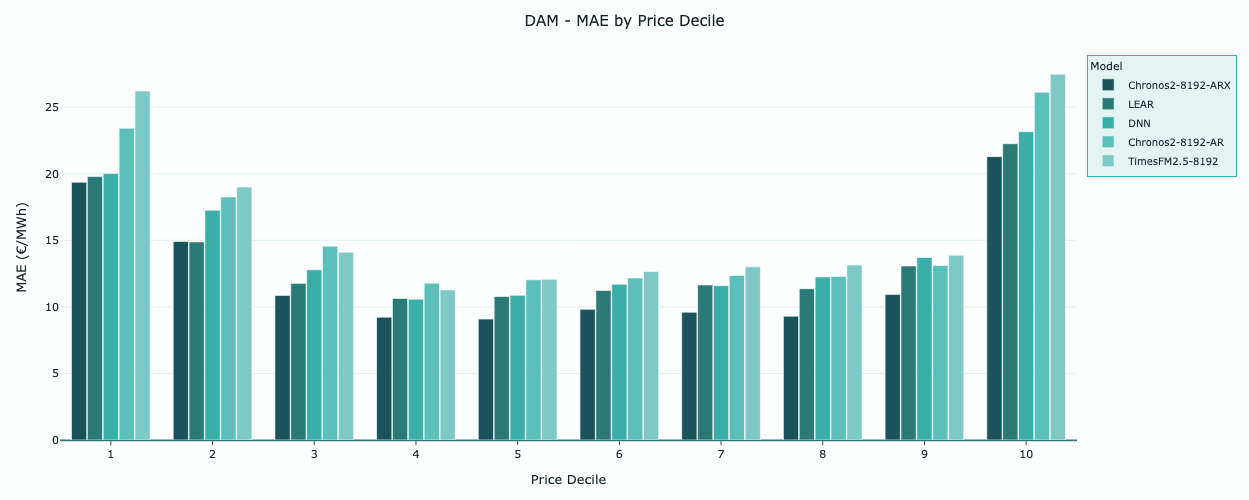

In [53]:
TEAL_PALETTE = [
    '#1a535c',  # dark teal-blue   — Chronos2-ARX (best model, darkest)
    '#2b7a78',  # deep teal        — LEAR
    '#3aafa9',  # mid teal         — DNN
    '#5bbfba',  # light-mid teal   — Chronos2-AR
    '#7ec8c8',  # pale teal        — TimesFM (worst, lightest)
]

dam_display = {
    'chronos2_8192_ARX_temporal': 'Chronos2-8192-ARX',
    'LEAR':                        'LEAR',
    'DNN':                         'DNN',
    'chronos2_8192_AR':            'Chronos2-8192-AR',
    'timesfm25_8192_AR_neg':       'TimesFM2.5-8192',
}

fig = go.Figure()
for i, (col, label) in enumerate(dam_display.items()):
    fig.add_trace(go.Bar(
        x=decile_mae_dam.index,
        y=decile_mae_dam[col],
        name=label,
        marker=dict(
            color=TEAL_PALETTE[i],
            line=dict(color='#feffff', width=0.6),
        ),
    ))

fig.update_layout(
    barmode='group',
    width=1200, height=500,
    template='plotly_white',

    title=dict(
        text='DAM - MAE by Price Decile',
        font=dict(size=15, color='#17252a'),
        x=0.5, xanchor='center', y=0.97,
    ),

    paper_bgcolor='#feffff',
    plot_bgcolor='#feffff',

    xaxis=dict(
        title='Price Decile',
        title_font=dict(size=13, color='#17252a'),
        tickfont=dict(size=11, color='#17252a'),
        tickmode='array',
        tickvals=decile_mae_dam.index,   # show ALL deciles
        showgrid=False,
        linecolor='#2b7a78',
        linewidth=1.2,
        ticks='outside', ticklen=4,
    ),
    yaxis=dict(
        title='MAE (€/MWh)',
        title_font=dict(size=13, color='#17252a'),
        tickfont=dict(size=11, color='#17252a'),
        gridcolor='#def2f1',
        gridwidth=1,
        zeroline=True, zerolinecolor='#2b7a78', zerolinewidth=1.2,
        rangemode='tozero',
    ),

    legend=dict(
    title=dict(text='Model', font=dict(size=11, color='#17252a')),
    font=dict(size=10, color='#17252a'),
    bgcolor='rgba(222,242,241,0.85)',
    bordercolor='#3aafa9',
    borderwidth=1,
    x=1.01, y=1.0,
    xanchor='left', yanchor='top',
    orientation='v',
        
),


    bargap=0.22,
    bargroupgap=0.04,

    margin=dict(l=60, r=150, t=55, b=60),  # increase right margin to make room
)

fig.show()
fig.write_image("figures/dam_mae_decile.png")

In [54]:
22.3/21.3

1.0469483568075117

In [ ]:
fig2 = go.Figure()
for col in dam_display:
    fig2.add_trace(go.Bar(
        x=decile_rmse_dam.index,
        y=decile_rmse_dam[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig2.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='DAM — RMSE by Price Decile (2024)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='RMSE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig2.show()

In [ ]:
# LaTeX: decile MAE at deciles 1, 5, 10
print(decile_mae_dam[dam_display].T[[1, 5, 10]].round(2).to_latex(float_format='{:.2f}'.format))

### 4b. IMB — decile MAE and RMSE (using baseline + new models)

In [51]:
imb_df['price_decile'] = pd.qcut(imb_df['price'], q=10, labels=False) + 1

imb_model_cols = [c for c in imb_df.columns if c not in {'QH', 'price', 'price_decile','timestamp'}]

decile_mae_imb = pd.DataFrame()
decile_rmse_imb = pd.DataFrame()
ae_imb = imb_df[['price_decile']].copy()
se_imb = imb_df[['price_decile']].copy()

for col in imb_model_cols:
    ae_imb[col] = (imb_df[col] - imb_df['price']).abs()
    se_imb[col] = (imb_df[col] - imb_df['price']) ** 2
    decile_mae_imb[col] = ae_imb.groupby('price_decile')[col].mean()
    decile_rmse_imb[col] = np.sqrt(se_imb.groupby('price_decile')[col].mean())

# Add new raw IMB models (need to assign deciles using actual price from imb_df price range)
# for model_name, df_new in new_imb.items():
#     df_new = df_new.dropna().copy()
#     df_new['price_decile'] = pd.qcut(df_new['price'], q=10, labels=False) + 1
#     df_new['AE'] = (df_new[model_name] - df_new['price']).abs()
#     df_new['SE'] = (df_new[model_name] - df_new['price']) ** 2
#     decile_mae_imb[model_name] = df_new.groupby('price_decile')['AE'].mean()
#     decile_rmse_imb[model_name] = np.sqrt(df_new.groupby('price_decile')['SE'].mean())

print('IMB decile MAE:')
decile_mae_imb.round(2)

IMB decile MAE:


,chronosbolt_AR,chronos2_AR,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,...,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,chronos2_lora_tuned,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
price_decile,,,,,,,,,,,,,,,,,,,,,
1,226.56,217.78,226.50,210.89,209.04,212.07,200.17,224.60,206.17,206.37,...,209.05,211.92,222.96,219.89,214.26,215.50,222.85,216.55,217.78,210.01
2,97.28,90.67,93.81,78.22,82.66,81.16,81.11,98.90,84.14,81.60,...,80.79,82.84,94.65,90.54,85.27,85.57,94.24,86.53,90.67,80.64
3,87.49,85.95,86.86,81.31,72.45,81.70,72.24,90.37,76.61,74.33,...,75.63,79.49,85.99,87.08,81.93,81.43,85.90,84.08,85.95,76.58
4,60.17,59.63,58.84,61.66,52.18,62.25,51.75,64.28,57.74,53.32,...,54.73,56.72,58.43,60.76,58.11,57.18,58.51,59.81,59.63,54.66
5,49.92,49.81,49.61,52.45,50.94,54.34,54.72,51.82,57.21,52.73,...,50.39,49.14,48.09,51.56,50.62,48.76,48.88,51.10,49.81,48.50
6,39.68,41.37,41.56,43.49,42.49,39.91,47.30,39.46,45.95,44.03,...,40.02,38.32,39.94,42.37,39.63,37.79,41.71,41.46,41.37,37.72
7,45.31,45.94,45.86,49.61,50.68,46.02,54.31,44.43,52.42,50.98,...,47.18,44.02,43.74,46.68,44.50,43.11,44.49,46.50,45.94,44.08
8,61.96,60.81,62.15,65.68,68.75,62.38,69.95,58.80,66.80,66.10,...,63.84,60.59,60.43,61.59,60.87,60.13,60.84,62.59,60.81,60.99
9,91.19,89.38,91.35,89.02,97.58,88.53,96.81,87.15,93.48,92.82,...,91.86,91.21,89.61,90.42,90.77,89.86,90.89,92.77,89.38,90.61


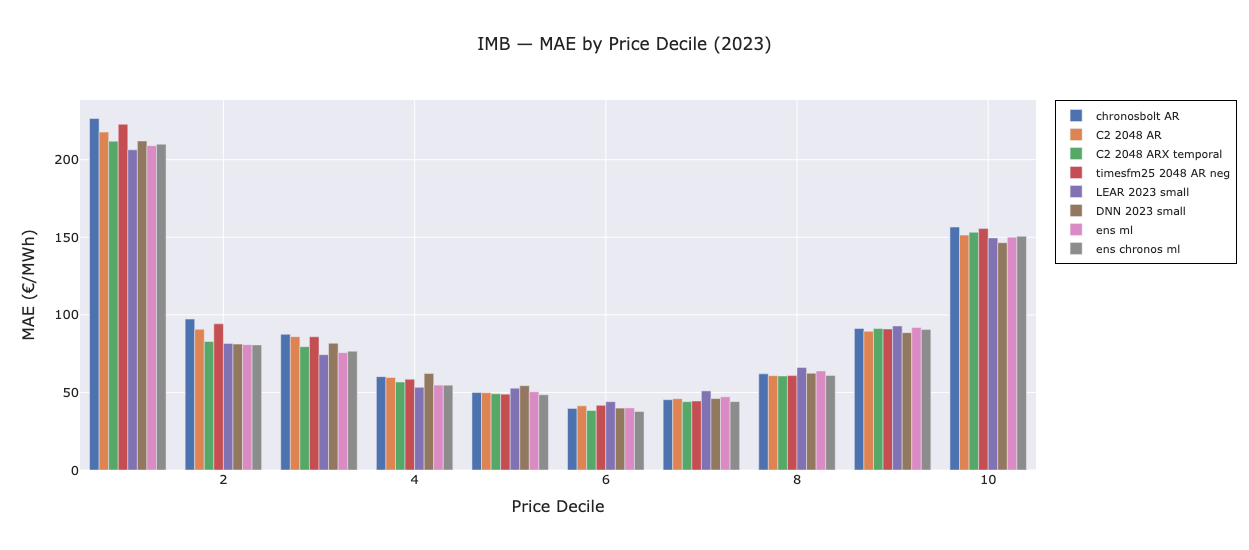

In [52]:
imb_display = [
    'chronosbolt_AR', 'chronos2_2048_AR', 'chronos2_2048_ARX_temporal', 'timesfm25_2048_AR_neg',
    'LEAR_2023_small', 'DNN_2023_small',  'ens_ml', 'ens_chronos_ml',#'ens_tsfm',
    # 'chronos2_512_ARX_temporal', 'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal',
]
imb_display = [c for c in imb_display if c in decile_mae_imb.columns]

fig = go.Figure()
for col in imb_display:
    fig.add_trace(go.Bar(
        x=decile_mae_imb.index,
        y=decile_mae_imb[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='IMB — MAE by Price Decile (2023)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='MAE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig.show()

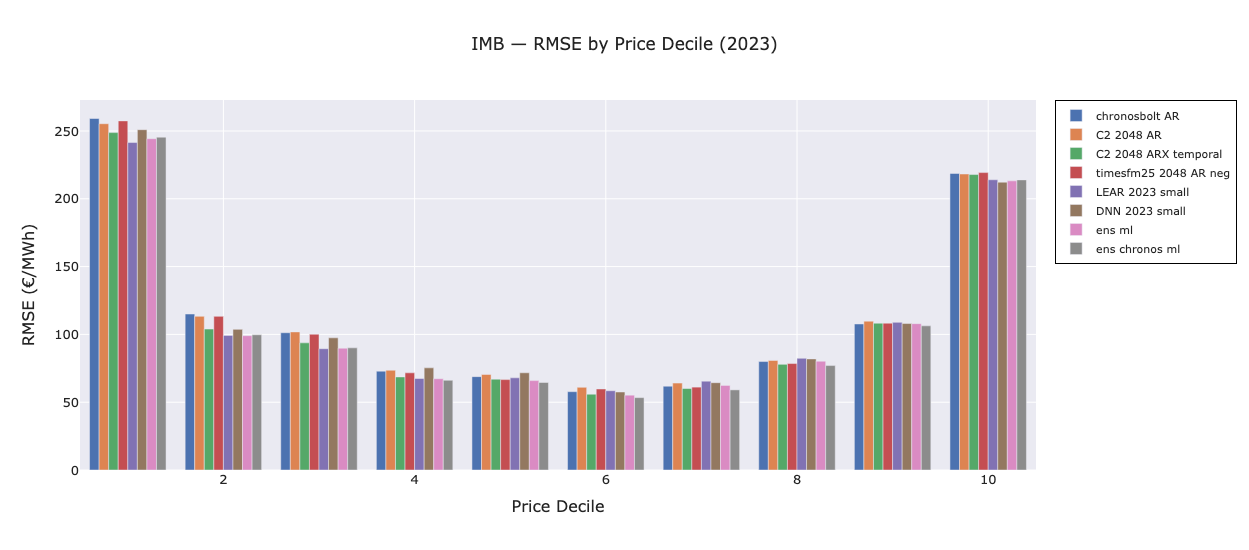

In [53]:
fig2 = go.Figure()
for col in imb_display:
    fig2.add_trace(go.Bar(
        x=decile_rmse_imb.index,
        y=decile_rmse_imb[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig2.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='IMB — RMSE by Price Decile (2023)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='RMSE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig2.show()

In [ ]:
# LaTeX: decile MAE at deciles 1, 5, 10
print(decile_mae_imb[imb_display].T[[1, 5, 10]].round(2).to_latex(float_format='{:.2f}'.format))